In [ ]:
from google.colab import files
files.upload()

Saving order_items_clean.csv to order_items_clean.csv
Saving orders_clean.csv to orders_clean.csv
Saving products_clean.csv to products_clean.csv
Saving reviews_clean.csv to reviews_clean.csv
Saving customers_clean.csv to customers_clean.csv


{'order_items_clean.csv': b'item_id,order_id,product_id,quantity,unit_price_idr,subtotal_idr,calculated_subtotal\nITM000001,ORD000001,PRD070,1,349000,349000,349000\nITM000002,ORD000001,PRD001,2,599000,1198000,1198000\nITM000003,ORD000001,PRD148,1,449000,449000,449000\nITM000004,ORD000002,PRD086,1,329000,329000,329000\nITM000005,ORD000002,PRD258,1,129000,129000,129000\nITM000006,ORD000002,PRD256,1,49000,49000,49000\nITM000007,ORD000003,PRD076,1,199000,199000,199000\nITM000008,ORD000004,PRD205,1,119000,119000,119000\nITM000009,ORD000005,PRD239,2,179000,358000,358000\nITM000010,ORD000006,PRD170,1,349000,349000,349000\nITM000011,ORD000007,PRD013,1,149000,149000,149000\nITM000012,ORD000007,PRD230,2,129000,258000,258000\nITM000013,ORD000008,PRD281,1,149000,149000,149000\nITM000014,ORD000008,PRD290,3,279000,837000,837000\nITM000015,ORD000009,PRD202,1,249000,249000,249000\nITM000016,ORD000010,PRD034,1,279000,279000,279000\nITM000017,ORD000011,PRD191,3,49000,147000,147000\nITM000018,ORD000011,P

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

custumers = pd.read_csv('/content/customers_clean.csv')
orders= pd.read_csv("/content/orders_clean.csv")
order_items= pd.read_csv('/content/order_items_clean.csv')

In [ ]:
orders.dtypes

,0
order_id,object
customer_id,object
order_date,object
total_amount_idr,int64
shipping_city,object
shipping_province,object
shipping_cost_idr,int64
payment_method,object
order_status,object
promo_code,object


In [ ]:
orders['order_date']= pd.to_datetime(orders['order_date'])

In [ ]:
orders.dtypes

,0
order_id,object
customer_id,object
order_date,datetime64[ns]
total_amount_idr,int64
shipping_city,object
shipping_province,object
shipping_cost_idr,int64
payment_method,object
order_status,object
promo_code,object


In [ ]:
'''customers → Who is buying?
orders → What did they order and spend?
order_items → How many items were inside each order?'''

'customers → Who is buying?\norders → What did they order and spend?\norder_items → How many items were inside each order?'

In [ ]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()
'''Keep only successfully delivered orders for customer spending analysis.
I used delivered orders so cancelled or unsuccessful orders were not counted as completed sales.”'''

'Keep only successfully delivered orders for customer spending analysis.\nI used delivered orders so cancelled or unsuccessful orders were not counted as completed sales.”'

In [ ]:
customer_orders = delivered_orders.merge(
    custumers,
    on="customer_id",
    how="left"
)

customer_orders.head()

,order_id,customer_id,order_date,total_amount_idr,shipping_city,shipping_province,shipping_cost_idr,payment_method,order_status,promo_code,...,is_delivered,used_discount,name,email,phone,city,province,registration_date,gender,age_group
0,ORD000002,CUST0478,2025-02-26,507000,Palembang,Sumatera Selatan,33769,Kartu Kredit,delivered,No Promo,...,1,0,Aditya Lestari,adityalestari115@yahoo.com,87881898471.0,Palembang,Sumatera Selatan,2024-05-13,Male,18-24
1,ORD000003,CUST0306,2022-07-13,199000,Tangerang,Banten,12060,Transfer Bank,delivered,No Promo,...,1,0,Alya Hartono,alyahartono174@gmail.com,89505302146.0,Tangerang,Banten,2024-10-03,Female,25-34
2,ORD000007,CUST0170,2022-02-05,407000,Bekasi,Jawa Barat,13600,Transfer Bank,delivered,No Promo,...,1,0,Indra Utami,indrautami201@gmail.com,85712406596.0,Bekasi,Jawa Barat,2023-06-21,Male,25-34
3,ORD000010,CUST0200,2023-04-14,264669,Pontianak,Kalimantan Barat,30484,GoPay,delivered,HARI BELANJA,...,1,1,Vania Hidayat,vaniahidayat716@outlook.com,85630316179.0,Pontianak,Kalimantan Barat,2021-04-23,Female,25-34
4,ORD000011,CUST0225,2023-03-30,226000,Bekasi,Jawa Barat,9935,Transfer Bank,delivered,No Promo,...,1,0,Hana Ginting,hanaginting167@yahoo.com,85710405411.0,Bekasi,Jawa Barat,2021-12-15,Female,35-44


In [ ]:
customers = custumers

In [ ]:
customer_orders = delivered_orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [ ]:
#after merging Order + Customer information contains Order + Customer information
orders_per_customer = (
    delivered_orders
    .groupby("customer_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

In [ ]:
print(len(orders_per_customer))

717


In [ ]:
#One-Time vs Repeat Customers
customer_frequency = (
    delivered_orders
    .groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

In [ ]:
customer_frequency["customer_type"] = customer_frequency[
    "order_count"
].apply(
    lambda x: "Repeat Customer"
    if x > 1 else "One-Time Customer"
)

In [ ]:
#shows the number of one-time and repeat customers.
customer_frequency["customer_type"].value_counts()

,count
customer_type,
Repeat Customer,509
One-Time Customer,208


In [ ]:
#shows the percentage.
customer_frequency["customer_type"].value_counts(
    normalize=True
) * 100

,proportion
customer_type,
Repeat Customer,70.990237
One-Time Customer,29.009763


In [ ]:
#Customer Spending
customer_spending = (
    delivered_orders
    .groupby("customer_id")["total_amount_idr"]
    .sum()
    .reset_index(name="total_spent")
)

In [57]:
#Customer Spendings
top_customers = (
    customer_spending
    .sort_values(
        "total_spent",
        ascending=False
    )
    .head(10)
)

In [ ]:
print(top_customers)

    customer_id  total_spent
425    CUST0474      5851769
442    CUST0492      4865145
357    CUST0399      4644956
206    CUST0233      4377525
651    CUST0729      4189992
189    CUST0215      4098048
406    CUST0453      4027093
710    CUST0792      3965729
448    CUST0498      3837251
550    CUST0618      3800310


In [ ]:
#Add Customer Names
top_customers = top_customers.merge(
    customers[
        ["customer_id", "name"]
    ],
    on="customer_id",
    how="left"
)

<Axes: ylabel='name'>

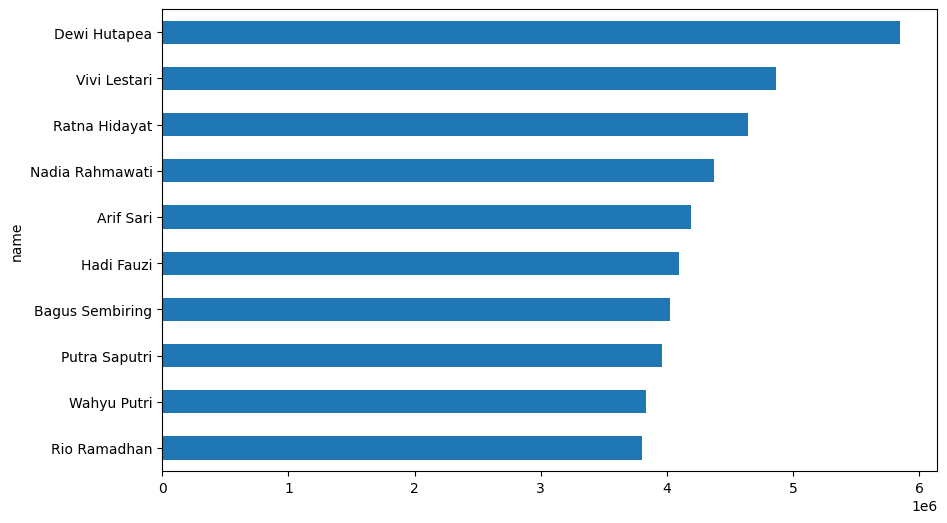

In [ ]:
top_customers.sort_values(
    "total_spent"
).plot(
    x="name",
    y="total_spent",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

In [ ]:
#Average Customer Spending
average_customer_spending = (
    customer_spending["total_spent"].mean()
)
print(average_customer_spending)

1224200.9051603905


In [ ]:
#Customer Analysis by Age Group
age_group_orders = (
    customer_orders
    .groupby("age_group")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)
print(age_group_orders)

age_group
25-34    735
18-24    462
35-44    428
45+      151
Name: order_id, dtype: int64


In [ ]:
age_group_revenue = (
    customer_orders
    .groupby("age_group")["total_amount_idr"]
    .sum()
    .sort_values(ascending=False)
)
print(age_group_revenue)

age_group
25-34    372927064
18-24    218061248
35-44    207925163
45+       78838574
Name: total_amount_idr, dtype: int64


In [ ]:
#Customer Analysis by Gender
gender_orders = (
    customer_orders
    .groupby("gender")["order_id"]
    .nunique()
)
gender_orders

,order_id
gender,
Female,1023
Male,753


In [ ]:
gender_revenue = (
    customer_orders
    .groupby("gender")["total_amount_idr"]
    .sum()
)
gender_revenue

,total_amount_idr
gender,
Female,506631425
Male,371120624


In [ ]:
#Order Value Distribution
delivered_orders["total_amount_idr"].describe()

,total_amount_idr
count,1.776000e+03
mean,4.942298e+05
std,3.802275e+05
min,2.357000e+03
25%,1.990000e+05
50%,3.990000e+05
75%,6.854238e+05
max,2.537438e+06


(array([143., 215., 197., 207., 176., 143., 132., 113.,  91.,  65.,  53.,
         53.,  49.,  30.,  29.,  22.,  18.,   8.,   7.,   9.,   5.,   1.,
          0.,   6.,   0.,   0.,   0.,   1.,   2.,   1.]),
 array([2.3570000e+03, 8.6859700e+04, 1.7136240e+05, 2.5586510e+05,
        3.4036780e+05, 4.2487050e+05, 5.0937320e+05, 5.9387590e+05,
        6.7837860e+05, 7.6288130e+05, 8.4738400e+05, 9.3188670e+05,
        1.0163894e+06, 1.1008921e+06, 1.1853948e+06, 1.2698975e+06,
        1.3544002e+06, 1.4389029e+06, 1.5234056e+06, 1.6079083e+06,
        1.6924110e+06, 1.7769137e+06, 1.8614164e+06, 1.9459191e+06,
        2.0304218e+06, 2.1149245e+06, 2.1994272e+06, 2.2839299e+06,
        2.3684326e+06, 2.4529353e+06, 2.5374380e+06]),
 <BarContainer object of 30 artists>)

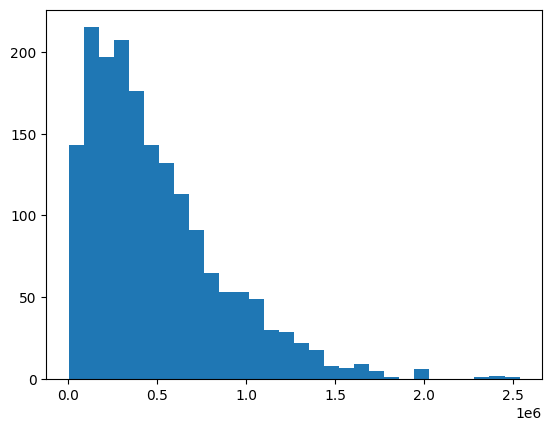

In [ ]:
#creates a histogram.
plt.hist(
    delivered_orders["total_amount_idr"],
    bins=30
)

In [ ]:
#Items per Order
items_per_order = (
    order_items
    .groupby("order_id")["quantity"]
    .sum()
    .reset_index(name="items_count")
)
items_per_order.head()

,order_id,items_count
0,ORD000001,4
1,ORD000002,3
2,ORD000003,1
3,ORD000004,1
4,ORD000005,2


In [ ]:
order_analysis = delivered_orders.merge(
    items_per_order,
    on="order_id",
    how="left"
)
order_analysis

,order_id,customer_id,order_date,total_amount_idr,shipping_city,shipping_province,shipping_cost_idr,payment_method,order_status,promo_code,...,courier,year,month,month_num,year_month,is_cancelled,is_returned,is_delivered,used_discount,items_count
0,ORD000002,CUST0478,2025-02-26,507000,Palembang,Sumatera Selatan,33769,Kartu Kredit,delivered,No Promo,...,JNE,2025,February,2,2025-02,0,0,1,0,3
1,ORD000003,CUST0306,2022-07-13,199000,Tangerang,Banten,12060,Transfer Bank,delivered,No Promo,...,SiCepat,2022,July,7,2022-07,0,0,1,0,1
2,ORD000007,CUST0170,2022-02-05,407000,Bekasi,Jawa Barat,13600,Transfer Bank,delivered,No Promo,...,JNE,2022,February,2,2022-02,0,0,1,0,3
3,ORD000010,CUST0200,2023-04-14,264669,Pontianak,Kalimantan Barat,30484,GoPay,delivered,HARI BELANJA,...,Pos Indonesia,2023,April,4,2023-04,0,0,1,1,1
4,ORD000011,CUST0225,2023-03-30,226000,Bekasi,Jawa Barat,9935,Transfer Bank,delivered,No Promo,...,Anteraja,2023,March,3,2023-03,0,0,1,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1771,ORD002991,CUST0609,2024-05-16,328000,Bekasi,Jawa Barat,11802,OVO,delivered,No Promo,...,Pos Indonesia,2024,May,5,2024-05,0,0,1,0,2
1772,ORD002992,CUST0224,2023-05-09,449240,Depok,Jawa Barat,12128,GoPay,delivered,RAMADAN23,...,J&T,2023,May,5,2023-05,0,0,1,1,2
1773,ORD002995,CUST0414,2024-05-27,817000,Surabaya,Jawa Timur,16493,QRIS,delivered,No Promo,...,SiCepat,2024,May,5,2024-05,0,0,1,0,3
1774,ORD002996,CUST0570,2024-05-31,518000,Tangerang,Banten,11227,Transfer Bank,delivered,No Promo,...,SiCepat,2024,May,5,2024-05,0,0,1,0,2


In [ ]:
order_analysis["items_count"].mean()

np.float64(2.1300675675675675)

In [ ]:
#Create Customer Summary Table
customer_summary = (
    customer_frequency
    .merge(
        customer_spending,
        on="customer_id",
        how="left"
    )
    .merge(
        customers[
            [
                "customer_id",
                "name",
                "city",
                "province",
                "gender",
                "age_group"
            ]
        ],
        on="customer_id",
        how="left"
    )
)
customer_summary

,customer_id,order_count,customer_type,total_spent,name,city,province,gender,age_group
0,CUST0001,4,Repeat Customer,2651604,Andi Rahmawati,Semarang,Jawa Tengah,Male,25-34
1,CUST0002,1,One-Time Customer,349000,Sari Sembiring,Semarang,Jawa Tengah,Female,18-24
2,CUST0003,4,Repeat Customer,1802000,Bella Aprilia,Tangerang,Banten,Female,18-24
3,CUST0004,1,One-Time Customer,119000,Shinta Hartono,Semarang,Jawa Tengah,Female,25-34
4,CUST0005,4,Repeat Customer,1720644,Maulana Hidayat,Bekasi,Jawa Barat,Male,18-24
...,...,...,...,...,...,...,...,...,...
712,CUST0794,4,Repeat Customer,3067634,Indah Nugroho,Pekanbaru,Riau,Female,35-44
713,CUST0795,1,One-Time Customer,145972,Doni Setiawan,Jakarta,Dki Jakarta,Male,35-44
714,CUST0797,3,Repeat Customer,2515024,Siti Maharani,Banjarmasin,Kalimantan Selatan,Female,18-24
715,CUST0798,2,Repeat Customer,895000,Pandu Iskandar,Yogyakarta,Di Yogyakarta,Male,25-34


In [ ]:
'''
## Day 3 Business Observations

- The highest-spending customer was ______.
- ______% of purchasing customers were repeat customers.
- Average customer spending was Rp ______.
- The highest-revenue age group was ______.
- The age group with the highest order count was ______.
- Average items per delivered order was ______.
- Most delivered order values were concentrated around ______.
'''

In [ ]:
import os

os.makedirs("/content/Processed", exist_ok=True)

customer_summary.to_csv(
    "/content/Processed/customer_summary.csv",
    index=False
)

print("Customer summary saved!")

Customer summary saved!


In [ ]:
from google.colab import files

files.download("/content/Processed/customer_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>